# EDA for `restaurant_dataset.csv` 

This notebook quickly summarizes key statistics:
1. Info, shape and missing values
2. Number of different queries
3. Number of different restaurants by ID and display examples
4. Label distribution
5. Top 10 most frequently appearing restaurants
6. Top 10 most frequently appearing districts
7. Top 10 most common cuisines

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)
pd.set_option('display.max_colwidth', 120)

In [2]:
df = pd.read_csv('restaurant_dataset.csv')
display(df.head(5))

,query,restaurant_name,restaurant_id,label,reason,district,cuisines,source
0,Tôi muốn tìm 1 quán ăn hải sản ở quận 6 cho tối thứ sáu,Hải Sản Biển Đêm,768951,0,"Sai quận, quán ở Quận 9 không phải Quận 6",Quận 9,Món Miền Nam,pinecone
1,Tôi muốn tìm 1 quán ăn hải sản ở quận 6 cho tối thứ sáu,Biển Nhà Tôi - Quán Ăn Hải Sản,758278,0,"Sai quận, quán ở Huyện Cần Giờ không phải Quận 6",Huyện Cần Giờ,Món Việt,pinecone
2,Tôi muốn tìm 1 quán ăn hải sản ở quận 6 cho tối thứ sáu,Quán Hải Sản 68,922987,4,"Quán hải sản đúng quận 6, mở cửa tối thứ sáu phù hợp",Quận 6,Món Việt,pinecone
3,Tôi muốn tìm 1 quán ăn hải sản ở quận 6 cho tối thứ sáu,Ẩm Thực 214 - Hải Sản Tươi Sống,895273,0,"Sai quận, quán ở Quận Gò Vấp không phải Quận 6",Quận Gò Vấp,Món Việt,pinecone
4,Tôi muốn tìm 1 quán ăn hải sản ở quận 6 cho tối thứ sáu,Quán Hải Sản Cần Giờ,224879,0,"Sai quận, quán ở Quận 7 không phải Quận 6",Quận 7,Món Việt,pinecone


## 1. Load the dataset and check basic info, shape and missing values

In [3]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Rows: 7500, Columns: 8


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   query            7500 non-null   object
 1   restaurant_name  7500 non-null   object
 2   restaurant_id    7500 non-null   int64 
 3   label            7500 non-null   int64 
 4   reason           7500 non-null   object
 5   district         7500 non-null   object
 6   cuisines         7421 non-null   object
 7   source           7500 non-null   object
dtypes: int64(2), object(6)
memory usage: 468.9+ KB


In [5]:
missing = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_percent': (df.isna().mean() * 100).round(2)
}).sort_values(by='missing_count', ascending=False)

display(missing)

,missing_count,missing_percent
cuisines,79,1.05
query,0,0.00
restaurant_id,0,0.00
restaurant_name,0,0.00
label,0,0.00
reason,0,0.00
district,0,0.00
source,0,0.00


## 2. Count the number of different queries

In [6]:
query_col = "query"

query_normalized = df[query_col].astype(str).str.strip().str.lower()
diff_query = query_normalized.nunique()

print(f"The number of unique queries is: {diff_query}")
print("\nTop 10 queries that appear most frequently:")
display(query_normalized.value_counts().head(10).rename_axis("query").reset_index(name="frequency"))

The number of unique queries is: 500

Top 10 queries that appear most frequently:


,query,frequency
0,cho mình gợi ý một quán ăn ở quận 1 có không gian lịch sự và phù hợp cho buổi gặp mặt khách hàng vào trưa thứ hai,15
1,tôi muốn tìm 1 quán ăn hải sản ở quận 6 cho tối thứ sáu,15
2,hãy gợi ý cho tôi 1 quán ăn vặt quận bình thạnh,15
3,hãy cho tôi biết quán nào bán đồ hàn quốc ngon ở quận 1 để đi cuối tuần,15
4,tôi muốn tìm một quán ăn ở quận 7 có không gian đẹp,15
5,hãy gợi ý cho tôi 1 quán ăn ở quận 10 có giao hàng tận nơi,15
6,tôi muốn đặt bàn một nhà hàng ở quận 1 dành cho cặp đôi vào tối thứ bảy với không gian đẹp,15
7,hãy cho tôi biết những quán cafe được đánh giá cao ở quận 3 để đi chiều chủ nhật,15
8,quán ăn nào có giá cả phải chăng cho dân văn phòng ở quận tân bình,15
9,tôi muốn tìm một quán ăn ăn vặt đồ ăn hàn quốc cho sinh viên có giá cả tốt ở thủ đức,15


## 3. Count the number of unique restaurants (based on ID)

In [7]:
id_col = "restaurant_id"

unique_restaurants = df[id_col].nunique()
duplicate_rows = df.duplicated(subset=[id_col]).sum()

print(f"The number of unique restaurants by ID is: {unique_restaurants}")
print(f"The number of duplicate rows by ID is: {duplicate_rows}")

The number of unique restaurants by ID is: 3099
The number of duplicate rows by ID is: 4401


In [8]:
name_col = "restaurant_name"
label_col = "label"

query_per_id = (
    df.assign(_query_norm=df[query_col].astype(str).str.strip().str.lower())
      .groupby(id_col)["_query_norm"]
      .nunique()
 )

candidate_ids = query_per_id[query_per_id > 1].index

if len(candidate_ids) == 0:
    print("No restaurant ID has multiple different queries.")
else:
    sample_id = candidate_ids[0]
    duplicate_diff_query_example = (
        df[df[id_col] == sample_id][[query_col, name_col, id_col, label_col]]
        .drop_duplicates()
        .sort_values(by=query_col, key=lambda s: s.astype(str).str.lower())
    )
    print(f"Example restaurant_id with duplicate rows but different queries: {sample_id}")
    display(duplicate_diff_query_example)

Example restaurant_id with duplicate rows but different queries: 8


,query,restaurant_name,restaurant_id,label
5628,Cho mình một quán buffet ở quận 2 chất lượng ổn cho bữa trưa Chủ nhật,Buffet Hải Sản - Café Central An Đông - Khách Sạn Windsor Plaza,8,1
4239,Gợi ý quán buffet ở quận 2 chất lượng ổn và giá mềm cho bữa trưa Chủ nhật,Buffet Hải Sản - Café Central An Đông - Khách Sạn Windsor Plaza,8,0
2223,Mình cần quán buffet ở quận 10 có nhiều lượt xem và giá cả hợp lý,Buffet Hải Sản - Café Central An Đông - Khách Sạn Windsor Plaza,8,1
3318,Mình cần quán buffet ở quận 2 có nhiều món và giá hợp lý,Buffet Hải Sản - Café Central An Đông - Khách Sạn Windsor Plaza,8,1
5109,Mình cần quán buffet ở quận 5 nhiều lượt xem và phục vụ ổn,Buffet Hải Sản - Café Central An Đông - Khách Sạn Windsor Plaza,8,4
5797,Mình muốn tìm quán buffet ở quận 1 hợp giới manager cho bữa trưa thứ hai,Buffet Hải Sản - Café Central An Đông - Khách Sạn Windsor Plaza,8,0
1677,Mình muốn tìm quán buffet ở quận 10 có nhiều lượt yêu thích,Buffet Hải Sản - Café Central An Đông - Khách Sạn Windsor Plaza,8,2
2066,Ở quận 10 có quán buffet nào giá ổn mà chất lượng tốt không,Buffet Hải Sản - Café Central An Đông - Khách Sạn Windsor Plaza,8,0
5237,Ở quận 10 có quán buffet nào nhận đặt bàn cho tối cuối tuần không,Buffet Hải Sản - Café Central An Đông - Khách Sạn Windsor Plaza,8,0
3888,Ở quận 6 có quán buffet nào giá cả hợp lý không,Buffet Hải Sản - Café Central An Đông - Khách Sạn Windsor Plaza,8,0


## 4. Analyze label distribution

Label distribution (count and percentage):


,label,count,percentage
0,0,3908,52.11
1,1,1602,21.36
2,2,675,9.00
3,3,594,7.92
4,4,721,9.61


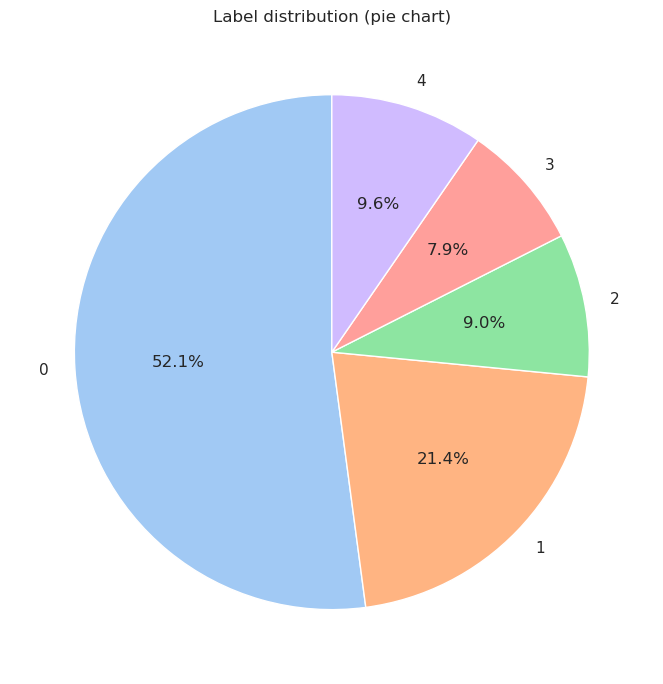

In [9]:
label_col = "label"

label_counts = df[label_col].value_counts(dropna=False).sort_index()
label_pct = (label_counts / len(df) * 100).round(2)

label_dist_df = pd.DataFrame({
    "label": label_counts.index,
    "count": label_counts.values,
    "percentage": label_pct.values,
})

print("Label distribution (count and percentage):")
display(label_dist_df)

plt.figure(figsize=(7, 7))
colors = sns.color_palette("pastel", n_colors=len(label_counts))
wedges, texts, autotexts = plt.pie(
    label_counts.values,
    labels=label_counts.index.astype(str),
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"edgecolor": "white", "linewidth": 1},
)
plt.title("Label distribution (pie chart)")
plt.tight_layout()
plt.show()

The distribution of relevance labels shows a clear class imbalance in the dataset. Label **0** dominates the dataset with **52.11%**, indicating that more than half of the query–restaurant pairs are considered **irrelevant**. Label **1** is the second most frequent with **21.36%**, while the remaining labels (**2, 3, 4**) each account for less than **10%** of the data.

This imbalance suggests that the dataset contains significantly more negative examples than highly relevant ones. Such a distribution is common in retrieval or ranking datasets where most candidate items are not strongly relevant to the query. However, this imbalance may affect model training and could require techniques such as **class weighting** or **balanced sampling** to ensure the model learns meaningful distinctions between higher relevance levels.

## 5. Top 10 most frequently appearing restaurants

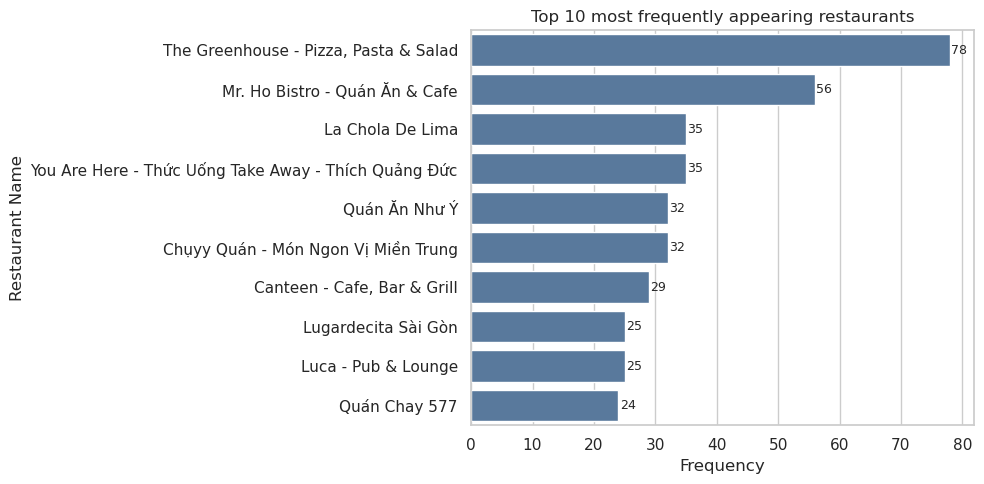

In [10]:
name_col = "restaurant_name"

top10_restaurants = (
    df[name_col]
    .astype(str)
    .str.strip()
    .value_counts()
    .head(10)
    .reset_index()
 )
top10_restaurants.columns = ["restaurant_name", "frequency"]

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=top10_restaurants,
    x="frequency",
    y="restaurant_name",
    color="#4e79a7"
 )

for patch in ax.patches:
    width = patch.get_width()
    y = patch.get_y() + patch.get_height() / 2
    ax.text(width + 0.2, y, f"{int(width)}", va="center", ha="left", fontsize=9)

plt.title("Top 10 most frequently appearing restaurants")
plt.xlabel("Frequency")
plt.ylabel("Restaurant Name")
plt.tight_layout()
plt.show()

Some restaurants appear repeatedly in the dataset. **The Greenhouse - Pizza, Pasta & Salad** appears the most (**78 times**), followed by **Mr. Ho Bistro** (**56 times**).

## 6. Top 10 most frequently appearing districts

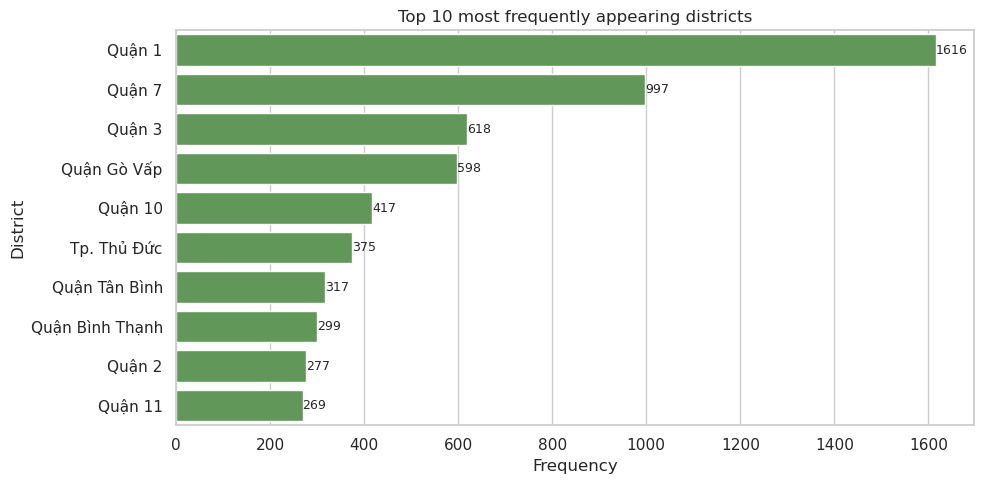

In [11]:
name_col = "district"

top10_restaurants = (
    df[name_col]
    .astype(str)
    .str.strip()
    .value_counts()
    .head(10)
    .reset_index()
 )
top10_restaurants.columns = ["district", "frequency"]

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=top10_restaurants,
    x="frequency",
    y="district",
    color="#59a14f"
 )

for patch in ax.patches:
    width = patch.get_width()
    y = patch.get_y() + patch.get_height() / 2
    ax.text(width + 0.2, y, f"{int(width)}", va="center", ha="left", fontsize=9)

plt.title("Top 10 most frequently appearing districts")
plt.xlabel("Frequency")
plt.ylabel("District")
plt.tight_layout()
plt.show()

The district distribution reveals that restaurant listings are heavily concentrated in central districts. **Quận 1** clearly dominates with **1,616 restaurants**, far exceeding other districts. The next highest are **Quận 7 (997)** and **Quận 3 (618)**.

This pattern reflects the urban structure of **Ho Chi Minh City**, where central districts tend to have a higher density of restaurants, tourism activity, and commercial areas. Consequently, the dataset is geographically skewed toward these districts. Models trained on this data may therefore implicitly learn a **location bias**, favoring restaurants located in central districts over those in suburban areas.

## 7. Top 10 most common cuisines

In [12]:
def split_multivalue_column(series):
    cleaned = (
        series.dropna()
        .astype('string')
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )
    exploded = cleaned.str.split(r'\s*\|\|\s*', regex=True).explode()
    exploded = exploded.astype('string').str.strip()
    exploded = exploded[(exploded.notna()) & (exploded != '')]
    return exploded

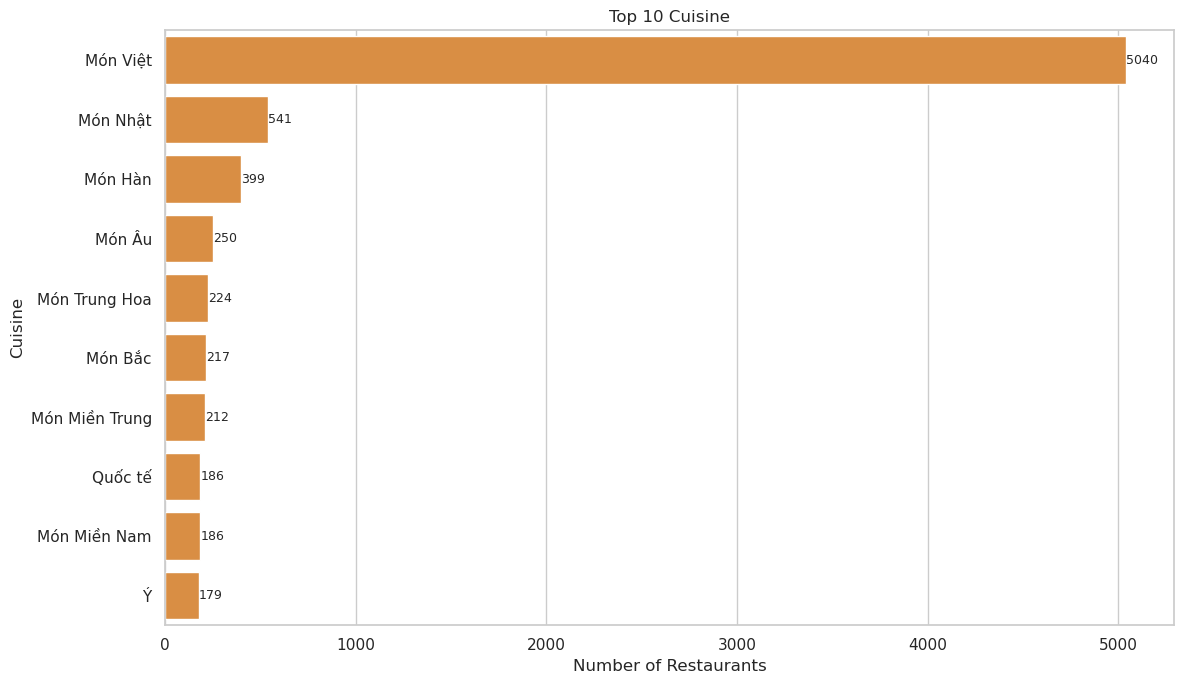

In [13]:
cuisine_exploded = split_multivalue_column(df['cuisines'])
cuisine_counts = cuisine_exploded.value_counts().head(10)

plt.figure(figsize=(12, 7))
ax = sns.barplot(x=cuisine_counts.values, y=cuisine_counts.index, color='#f28e2b')

for patch in ax.patches:
    width = patch.get_width()
    y = patch.get_y() + patch.get_height() / 2
    ax.text(width + 0.2, y, f"{int(width)}", va="center", ha="left", fontsize=9)

plt.title('Top 10 Cuisine')
plt.xlabel('Number of Restaurants')
plt.ylabel('Cuisine')
plt.tight_layout()
plt.show()

Cuisine distribution is highly skewed toward **Vietnamese cuisine**, which accounts for **5,040 restaurants**, far exceeding all other cuisine types. The second most common cuisine, **Japanese**, has only **541 restaurants**, followed by **Korean (399)** and **European (250)**.

This distribution reflects the local food culture, where Vietnamese cuisine naturally dominates the restaurant landscape. The presence of a significant number of Japanese and Korean restaurants indicates a demand for international cuisines, while the relatively lower counts for European and other cuisines suggest they are less prevalent in the area.